In [ ]:
import yfinance as yf
# 抓取 NVDA 過去兩年的資料
df = yf.download('NVDA', period='2y')

In [ ]:
import pandas as pd
import yfinance as yf

# ==========================================
# 1. 獲取數據 (Data Acquisition)
# ==========================================
print("正在連線至 Yahoo Finance 下載歷史數據...")
# 下載台積電過去一年的日K線資料，並將其存入變數 'df' 中
df = yf.download('2330.TW', period='1y')

# 檢查一下是否成功抓到資料
if df.empty:
    print("抓取資料失敗，請檢查網路或股票代號。")
else:
    print("資料下載成功！")

# ==========================================
# 2. 訊號生成 (Signal Generation)
# ==========================================
fast_window = 10
slow_window = 30

# 現在 df 已經有資料了，這行就不會再報錯了！
# 我們對 'Close' (收盤價) 進行滾動窗口計算平均值
df['Fast_MA'] = df['Close'].rolling(window=fast_window).mean()
df['Slow_MA'] = df['Close'].rolling(window=slow_window).mean()

# ==========================================
# 3. 輸出結果驗證
# ==========================================
print("\n計算完成！這是最近 5 天的收盤價與均線數據：")
# 只印出收盤價與我們剛算出來的兩條均線
print(df[['Close', 'Fast_MA', 'Slow_MA']].tail())

正在連線至 Yahoo Finance 下載 10 年期歷史數據...


[*********************100%***********************]  1 of 1 completed
C:\Users\andyw\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20729 (\N{CJK UNIFIED IDEOGRAPH-50F9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\andyw\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\andyw\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\andyw\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31309 (\N{CJK UNIFIED IDEOGRAPH-7A4D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\andyw\AppD

資料下載成功！準備繪圖...
正在生成圖表視窗...


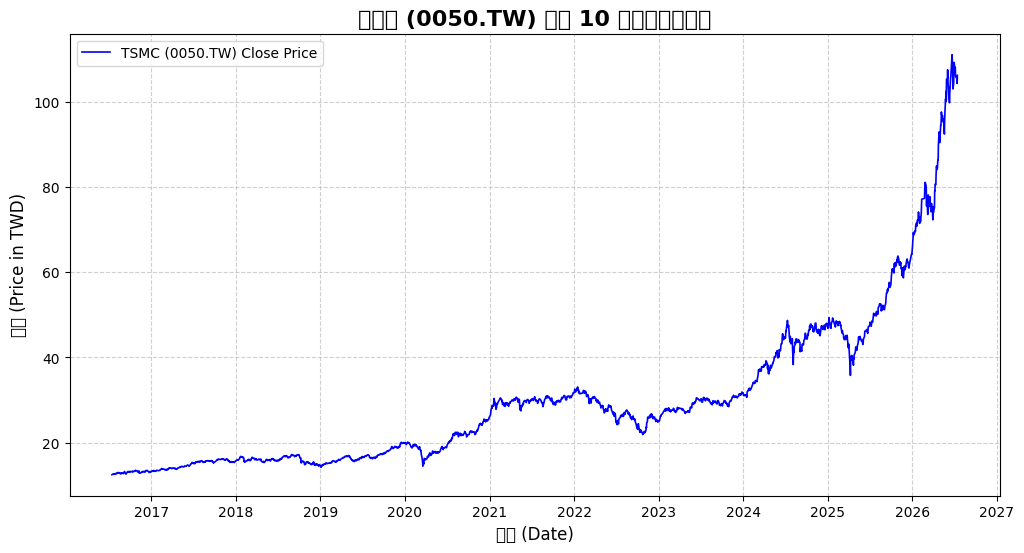

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt

# ==========================================
# 1. 獲取 10 年歷史數據
# ==========================================
print("正在連線至 Yahoo Finance 下載 10 年期歷史數據...")
# 透過設定 period='10y'，告訴 API 我們要抓過去 10 年的日 K 線資料
df = yf.download('0050.TW', period='10y')

if df.empty:
    print("抓取資料失敗，請檢查網路或股票代號。")
else:
    print("資料下載成功！準備繪圖...")

    # ==========================================
    # 2. 繪製歷史線圖 (Data Visualization)
    # ==========================================
    # 設定畫布大小 (寬度 12 英吋, 高度 6 英吋)
    plt.figure(figsize=(12, 6)) 
    
    # 畫出收盤價線。X軸為時間索引(df.index)，Y軸為收盤價(df['Close'])
    plt.plot(df.index, df['Close'], label='TSMC (0050.TW) Close Price', color='blue', linewidth=1.2)
    
    # 設定圖表標題與座標軸標籤
    plt.title('台積電 (0050.TW) 過去 10 年歷史價格線圖', fontsize=16, fontweight='bold')
    plt.xlabel('時間 (Date)', fontsize=12)
    plt.ylabel('價格 (Price in TWD)', fontsize=12)
    
    # 加上網格線，方便對齊價格 (就像示波器螢幕上的格線一樣)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # 顯示圖例 (標示藍線代表什麼)
    plt.legend()
    
    # ==========================================
    # 3. 輸出結果
    # ==========================================
    print("正在生成圖表視窗...")
    # 呼叫 show() 會彈出一個互動式視窗，你可以放大、縮小或存檔
    plt.show()

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt

# ==========================================
# 1. 獲取 10 年歷史數據
# ==========================================
print("正在連線至 Yahoo Finance 下載 5 年期歷史數據...")
df = yf.download('2330.TW', period='5y')

if df.empty:
    print("抓取資料失敗，請檢查網路或股票代號。")
else:
    print("資料下載成功！開始計算均線與繪圖...")

    # ==========================================
    # 2. 訊號生成 (Signal Generation)
    # ==========================================
    fast_window = 10
    slow_window = 30

    # 計算快線與慢線
    # 注意：最前面的 29 天因為數據不足以湊齊 30 天，算出來的值會是 NaN (空值)
    # 這在物理上就像是濾波器剛開機時的「初始化時間」，Matplotlib 畫圖時會自動忽略這些空值
    df['Fast_MA'] = df['Close'].rolling(window=fast_window).mean()
    df['Slow_MA'] = df['Close'].rolling(window=slow_window).mean()

    # ==========================================
    # 3. 繪製疊加線圖 (Data Visualization)
    # ==========================================
    # 設定畫布大小，稍微拉寬一點方便看 10 年的資料
    plt.figure(figsize=(14, 7)) 
    
    # 畫出收盤價 (半透明藍色，避免遮擋均線)
    plt.plot(df.index, df['Close'], label='收盤價 (Close)', color='blue', alpha=0.3, linewidth=1)
    
    # 畫出短期均線 (橘色，較粗)
    plt.plot(df.index, df['Fast_MA'], label=f'快線 ({fast_window}日均線)', color='darkorange', linewidth=1.5)
    
    # 畫出長期均線 (綠色，較粗)
    plt.plot(df.index, df['Slow_MA'], label=f'慢線 ({slow_window}日均線)', color='green', linewidth=1.5)
    
    # 設定標題與座標軸
    plt.title('台積電 (2330.TW) 10年價格與雙均線交叉策略圖', fontsize=16, fontweight='bold')
    plt.xlabel('時間 (Date)', fontsize=12)
    plt.ylabel('價格 (Price in TWD)', fontsize=12)
    
    # 加上網格線與圖例
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12)
    
    # ==========================================
    # 4. 顯示結果
    # ==========================================
    print("正在生成圖表視窗... (可使用視窗下方的放大鏡工具放大特定區間)")
    plt.show()

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

print("下載 10 年期歷史數據中...")
df = yf.download('2330.TW', period='10y')

if df.empty:
    print("資料抓取失敗。")
else:
    # 1. 計算均線與基礎訊號
    fast_window = 40
    slow_window = 100
    df['Fast_MA'] = df['Close'].rolling(window=fast_window).mean()
    df['Slow_MA'] = df['Close'].rolling(window=slow_window).mean()

    # 當快線大於慢線時，訊號為 1 (持有多單)，否則為 0 (空手)
    # np.where 就像是 Excel 的 IF 函數：np.where(條件, 成立給什麼, 不成立給什麼)
    df['Signal'] = np.where(df['Fast_MA'] > df['Slow_MA'], 1, 0)

    # 2. 避免未來函數 (Crucial Step!)
    # 將訊號往後推一天。今天的訊號，決定明天的部位 (Position)
    df['Position'] = df['Signal'].shift(1)

    # 3. 計算損益 (PnL Calculation)
    # 計算台積電每天的真實漲跌幅 (今天收盤價 / 昨天收盤價 - 1)
    df['Daily_Return'] = df['Close'].pct_change()

    # 計算策略的每天漲跌幅：只有當 Position 為 1 時，才能吃到 Daily_Return
    df['Strategy_Return'] = df['Position'] * df['Daily_Return']

    # 4. 計算累積報酬率 (Cumulative Return)
    # 把每天的 (1 + 漲跌幅) 乘起來，就可以得到從第一天到最後一天的總資產變化
    df['Cum_Market_Return'] = (1 + df['Daily_Return']).cumprod()
    df['Cum_Strategy_Return'] = (1 + df['Strategy_Return']).cumprod()

    # 5. 印出最終戰報
    # 抓取最後一天的數據來比較
    final_market = (df['Cum_Market_Return'].iloc[-1] - 1) * 100
    final_strategy = (df['Cum_Strategy_Return'].iloc[-1] - 1) * 100

    print("\n" + "="*40)
    print("📊 台積電 10年期雙均線策略回測報告")
    print("="*40)
    print(f"如果你這 10 年死抱台積電不放 (Buy & Hold)： 總報酬率 = {final_market:.2f}%")
    print(f"如果你嚴格執行 10日/30日 雙均線策略：     總報酬率 = {final_strategy:.2f}%")
    print("="*40)
    
    # 觀察：如果策略報酬輸給死抱不放，說明在多頭市場中，盤整期的假訊號摩擦成本吃掉了太多利潤。

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 獲取數據
# ==========================================
print("正在下載台積電 (2330.TW) 10年期數據...")
df = yf.download('2330.TW', period='10y')

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# ==========================================
# 2. 計算布林通道 (Bollinger Bands)
# ==========================================
ma_window = 20
k = 2
df['MA20'] = df['Close'].rolling(window=ma_window).mean()
df['Std20'] = df['Close'].rolling(window=ma_window).std()
df['Upper'] = df['MA20'] + (k * df['Std20'])
df['Lower'] = df['MA20'] - (k * df['Std20'])

# ==========================================
# 3. 策略邏輯實作
# ==========================================

# --- 策略 A: 均值回歸 (Mean Reversion) ---
# 買入訊號: 低於下軌; 賣出訊號: 回到中軌
df['Signal_Rev'] = 0
df.loc[df['Close'] < df['Lower'], 'Signal_Rev'] = 1 # 觸發買入
df.loc[df['Close'] > df['MA20'], 'Signal_Rev'] = 0  # 觸發平倉
df['Pos_Rev'] = df['Signal_Rev'].shift(1).ffill().fillna(0) # 訊號位移避免未來函數

# --- 策略 B: 突破策略 (Breakout) ---
# 買入訊號: 衝破上軌; 賣出訊號: 跌破中軌
df['Signal_Brk'] = 0
df.loc[df['Close'] > df['Upper'], 'Signal_Brk'] = 1 # 觸發買入
df.loc[df['Close'] < df['MA20'], 'Signal_Brk'] = 0  # 觸發平倉
df['Pos_Brk'] = df['Signal_Brk'].shift(1).ffill().fillna(0)

# ==========================================
# 4. 計算績效 (Performance)
# ==========================================
df['Daily_Ret'] = df['Close'].pct_change()
df['Rev_Ret'] = df['Pos_Rev'] * df['Daily_Ret']
df['Brk_Ret'] = df['Pos_Brk'] * df['Daily_Ret']

# 計算累積報酬率
df['Cum_BH'] = (1 + df['Daily_Ret']).cumprod()
df['Cum_Rev'] = (1 + df['Rev_Ret']).cumprod()
df['Cum_Brk'] = (1 + df['Brk_Ret']).cumprod()

# ==========================================
# 5. 輸出報告與繪圖
# ==========================================
print("\n" + "="*50)
print(f"📈 回測報告 (10年期)")
print(f"1. 死抱不放 (Buy & Hold): {((df['Cum_BH'].iloc[-1]-1)*100):.2f}%")
print(f"2. 均值回歸 (Mean Reversion): {((df['Cum_Rev'].iloc[-1]-1)*100):.2f}%")
print(f"3. 突破策略 (Breakout): {((df['Cum_Brk'].iloc[-1]-1)*100):.2f}%")
print("="*50)

plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Cum_BH'], label='Buy & Hold', alpha=0.5)
plt.plot(df.index, df['Cum_Rev'], label='Mean Reversion')
plt.plot(df.index, df['Cum_Brk'], label='Breakout')
plt.title('台積電策略回測對比 (10年)', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 獲取數據與計算指標
# ==========================================
print("正在下載台積電 (2330.TW) 10年期數據...")
df = yf.download('2330.TW', period='10y')

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

if df.empty:
    print("資料抓取失敗。")
else:
    # 確保資料照時間排序
    df = df.sort_index()
    
    # 計算基礎布林通道
    ma_window = 20
    k = 2
    df['MA20'] = df['Close'].rolling(window=ma_window).mean()
    df['Std20'] = df['Close'].rolling(window=ma_window).std()
    df['Upper'] = df['MA20'] + (k * df['Std20'])
    df['Lower'] = df['MA20'] - (k * df['Std20'])

    # 計算狀態濾波器：通道寬度 (BBW) 與其均線
    df['BBW'] = (df['Upper'] - df['Lower']) / df['MA20']
    df['BBW_MA'] = df['BBW'].rolling(window=20).mean()

    # ==========================================
    # 2. 狀態機交易邏輯 (State Machine Logic)
    # ==========================================
    print("正在執行混合策略回測運算...")
    
    # 初始化交易紀錄用的陣列
    signals = [0] * len(df)
    
    # 系統當前狀態變數
    current_position = 0      # 0 代表空手，1 代表持有多單
    strategy_mode = None      # 紀錄當下是用什麼邏輯進場的 ('REV' 均值回歸 或 'BRK' 突破)

    # 模擬每天的收盤行情，逐日進行決策
    for i in range(1, len(df)):
        # 如果指標還沒算出來 (前20天)，就跳過
        if pd.isna(df['MA20'].iloc[i]) or pd.isna(df['BBW_MA'].iloc[i]):
            continue

        close = df['Close'].iloc[i]
        upper = df['Upper'].iloc[i]
        lower = df['Lower'].iloc[i]
        ma20 = df['MA20'].iloc[i]
        bbw = df['BBW'].iloc[i]
        bbw_ma = df['BBW_MA'].iloc[i]

        # --- 步驟 A：檢查是否需要出場 (Exit Logic) ---
        if current_position == 1:
            # 如果是突破單：趨勢結束(跌破中軌)就停利/停損出場
            if strategy_mode == 'BRK' and close < ma20:
                current_position = 0
                strategy_mode = None
            # 如果是均值回歸單：反彈回到平衡點(突破中軌)就獲利了結
            elif strategy_mode == 'REV' and close > ma20:
                current_position = 0
                strategy_mode = None

        # --- 步驟 B：檢查是否需要進場 (Entry Logic) ---
        # 只有在空手時才尋找進場機會
        if current_position == 0:
            # 狀態 1：能量擴張且衝破上軌 -> 觸發【突破追擊】
            if bbw > bbw_ma and close > upper:
                current_position = 1
                strategy_mode = 'BRK'
            # 狀態 2：能量壓縮且跌破下軌 -> 觸發【均值回歸】
            elif bbw <= bbw_ma and close < lower:
                current_position = 1
                strategy_mode = 'REV'

        # 紀錄「今天收盤後」的持倉狀態，準備給明天開盤計算損益
        signals[i] = current_position

    # 將訊號存回 DataFrame，並向後平移一天避免未來函數
    df['Signal'] = signals
    df['Position'] = df['Signal'].shift(1).fillna(0)

    # ==========================================
    # 3. 損益結算與視覺化
    # ==========================================
    df['Daily_Ret'] = df['Close'].pct_change()
    df['Strategy_Ret'] = df['Position'] * df['Daily_Ret']

    df['Cum_BH'] = (1 + df['Daily_Ret']).cumprod()
    df['Cum_Strategy'] = (1 + df['Strategy_Ret']).cumprod()

    # 提取最後一天的總報酬率
    final_bh = (df['Cum_BH'].iloc[-1] - 1) * 100
    final_strat = (df['Cum_Strategy'].iloc[-1] - 1) * 100

    print("\n" + "="*50)
    print("🚀 混合自適應策略 (Adaptive System) 10年回測報告")
    print("="*50)
    print(f"死抱不放 (Buy & Hold) 總報酬: {final_bh:.2f}%")
    print(f"動態切換策略 總報酬:         {final_strat:.2f}%")
    print("="*50)

    # 繪製資金曲線
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['Cum_BH'], label='死抱不放 (Buy & Hold)', color='gray', alpha=0.6)
    plt.plot(df.index, df['Cum_Strategy'], label='動態混合策略 (Adaptive Strategy)', color='red', linewidth=2)
    plt.title('台積電 10年資金成長曲線對比', fontsize=16, fontweight='bold')
    plt.ylabel('資金倍數', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    print("正在生成績效走勢圖...")
    plt.show()

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

print("正在下載台積電 (6785.TWO) 5年期數據...")
df = yf.download('6785.TWO', period='5y')
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# ==========================================
# 1. 訊號處理：計算三大感測器數值
# ==========================================

# 感測器 A：MACD (利用指數移動平均 EMA)
df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = df['EMA12'] - df['EMA26']
df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

# 感測器 B：RSI 14日 (計算相對強弱)
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# 感測器 C：成交量濾網 (Volume)
df['Vol_MA20'] = df['Volume'].rolling(window=20).mean()

# ==========================================
# 2. 邏輯閘判斷 (Voting System)
# ==========================================
# 條件 1：MACD > Signal (動能向上)
cond_macd = df['MACD'] > df['Signal_Line']
# 條件 2：RSI 處於健康區間 (沒有極度超買)
cond_rsi = (df['RSI'] > 40) & (df['RSI'] < 70)
# 條件 3：帶量上攻 (今日成交量大於20日均量)
cond_vol = df['Volume'] > df['Vol_MA20']

# 綜合訊號：三個條件必須同時成立 (AND) 才買進
df['Buy_Signal'] = np.where(cond_macd & cond_rsi & cond_vol, 1, 0)

# 出場邏輯：MACD 死亡交叉，或是 RSI 跌破 40 就出場 (停損/停利)
df['Sell_Signal'] = np.where((df['MACD'] < df['Signal_Line']) | (df['RSI'] < 40), 1, 0)

# ==========================================
# 3. 狀態機持倉運算
# ==========================================
signals = [0] * len(df)
current_position = 0

for i in range(1, len(df)):
    if current_position == 0 and df['Buy_Signal'].iloc[i] == 1:
        current_position = 1
    elif current_position == 1 and df['Sell_Signal'].iloc[i] == 1:
        current_position = 0
    signals[i] = current_position

df['Position'] = pd.Series(signals, index=df.index).shift(1).fillna(0)

# ==========================================
# 4. 績效結算
# ==========================================
df['Daily_Ret'] = df['Close'].pct_change()
df['Strategy_Ret'] = df['Position'] * df['Daily_Ret']

final_bh = ((1 + df['Daily_Ret']).cumprod().iloc[-1] - 1) * 100
final_strat = ((1 + df['Strategy_Ret']).cumprod().iloc[-1] - 1) * 100

print("\n" + "="*50)
print("🎯 多指標共振系統 (MACD + RSI + Volume) 5年回測")
print("="*50)
print(f"死抱不放 (Buy & Hold): {final_bh:.2f}%")
print(f"多指標共振策略總報酬: {final_strat:.2f}%")
print("="*50)
print("💡 觀察點：利用量能與 RSI 濾掉假突破後，勝率會顯著提升。")

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ==========================================
# 1. 獲取數據與特徵工程 (Feature Engineering)
# ==========================================
print("正在下載台積電資料並製造 AI 特徵...")
df = yf.download('2330.TW', period='10y')
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 製造特徵 X (這會是 AI 學習的教材)
df['SMA_10'] = df['Close'].rolling(window=10).mean()
df['SMA_30'] = df['Close'].rolling(window=30).mean()
df['Dist_to_SMA10'] = (df['Close'] - df['SMA_10']) / df['SMA_10'] # 乖離率
df['Daily_Vol'] = df['Close'].pct_change().rolling(window=10).std() # 波動率
df['Volume_Ratio'] = df['Volume'] / df['Volume'].rolling(window=20).mean() # 成交量放大倍數

# 製造標籤 y (AI 要預測的目標：明天是否上漲？)
# 今天的收盤價 < 明天的收盤價，結果為 1，否則為 0
df['Target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

# 刪除因為計算均線或位移產生的空值 (NaN)
df = df.dropna()

# 挑選要餵給 AI 的特徵名稱
features = ['Dist_to_SMA10', 'Daily_Vol', 'Volume_Ratio']
X = df[features]
y = df['Target']

# ==========================================
# 2. 切分訓練集與測試集 (Train-Test Split)
# ==========================================
# 量化交易必須「照時間切」，不能隨機打散！
split_idx = int(len(df) * 0.8) # 80% 用來訓練，20% 用來考試

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
df_test = df.iloc[split_idx:].copy() # 保留測試集的原始資料用來算損益

# ==========================================
# 3. 建立與訓練隨機森林模型 (Model Training)
# ==========================================
print("正在訓練隨機森林大腦...")
# n_estimators=100 代表種植 100 棵決策樹
# random_state=42 確保每次跑的結果一致，方便除錯
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# 開始訓練 (Fitting)
model.fit(X_train, y_train)

# ==========================================
# 4. 預測與回測評估 (Prediction & Backtesting)
# ==========================================
print("正在對未知資料進行預測測試...")
# 讓訓練好的模型去預測測試集
df_test['AI_Signal'] = model.predict(X_test)

# 計算 AI 的預測準確率 (Directional Accuracy)
acc = accuracy_score(y_test, df_test['AI_Signal'])

# 算錢：如果 AI 預測 1 (會漲)，我們今天收盤就買進，賺明天的真實漲幅
df_test['Daily_Return'] = df_test['Close'].pct_change().shift(-1)
df_test['Strategy_Return'] = df_test['AI_Signal'] * df_test['Daily_Return']

# 累積報酬率 (從 1 開始乘)
df_test['Cum_BH'] = (1 + df_test['Daily_Return'].fillna(0)).cumprod()
df_test['Cum_AI'] = (1 + df_test['Strategy_Return'].fillna(0)).cumprod()

print("\n" + "="*50)
print("🤖 AI 隨機森林量化模型測試報告")
print("="*50)
print(f"方向預測準確率 (Accuracy): {acc*100:.2f}%")
print(f"測試期 (最後20%) 死抱不放報酬率: {((df_test['Cum_BH'].iloc[-2]-1)*100):.2f}%")
print(f"測試期 (最後20%) AI 策略報酬率:  {((df_test['Cum_AI'].iloc[-2]-1)*100):.2f}%")
print("="*50)

# 畫圖
plt.figure(figsize=(10, 5))
plt.plot(df_test.index, df_test['Cum_BH'], label='Buy & Hold')
plt.plot(df_test.index, df_test['Cum_AI'], label='AI Random Forest')
plt.title('AI 預測模型 vs 死抱不放 (測試集表現)')
plt.legend()
plt.show()

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 獲取 NVDA 歷史數據與降維處理
# ==========================================
print("正在連線至 Yahoo Finance 下載 NVDA 兩年期數據...")
df = yf.download('NVDA', period='2y')

# 處理 yfinance 新版多重索引問題
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.dropna()

# ==========================================
# 2. 核心訊號處理：計算 EMA (指數移動平均線)
# ==========================================
fast_span = 10
slow_span = 30

# 使用 ewm (Exponential Weighted Math) 計算 EMA
# span 代表時間跨度，adjust=False 是業界標準的遞迴算法
df['Fast_EMA'] = df['Close'].ewm(span=fast_span, adjust=False).mean()
df['Slow_EMA'] = df['Close'].ewm(span=slow_span, adjust=False).mean()

# ==========================================
# 3. 策略邏輯與回測運算
# ==========================================
# 產生訊號：快線 > 慢線 則持有多單 (1)，否則空手 (0)
df['Signal'] = np.where(df['Fast_EMA'] > df['Slow_EMA'], 1, 0)

# 位移一天，避免未來函數 (今天的交叉訊號，決定明天的部位)
df['Position'] = df['Signal'].shift(1).fillna(0)

# 計算日報酬率與策略報酬率
df['Daily_Ret'] = df['Close'].pct_change()
df['Strategy_Ret'] = df['Position'] * df['Daily_Ret']

# 計算累積資產倍數 (從 1 開始)
df['Cum_BH'] = (1 + df['Daily_Ret']).cumprod()
df['Cum_Strategy'] = (1 + df['Strategy_Ret']).cumprod()

# ==========================================
# 4. 數據視覺化 (Data Visualization)
# ==========================================
print("運算完成，正在生成分析圖表...")

# 建立 2x1 的子圖表架構 (上面看價格，下面看績效)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# --- 上半部：價格與 EMA 訊號圖 ---
ax1.plot(df.index, df['Close'], label='NVDA 收盤價', color='gray', alpha=0.4, linewidth=1)
ax1.plot(df.index, df['Fast_EMA'], label=f'Fast EMA ({fast_span})', color='darkorange', linewidth=1.5)
ax1.plot(df.index, df['Slow_EMA'], label=f'Slow EMA ({slow_span})', color='blue', linewidth=1.5)
ax1.set_title('NVDA (輝達) 兩年期雙 EMA 交叉策略', fontsize=16, fontweight='bold')
ax1.set_ylabel('價格 (USD)', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)

# --- 下半部：累積報酬率比較圖 ---
ax2.plot(df.index, df['Cum_BH'], label='死抱不放 (Buy & Hold)', color='gray', alpha=0.6)
ax2.plot(df.index, df['Cum_Strategy'], label='EMA 策略報酬', color='red', linewidth=2)
ax2.set_title('累積資產成長倍數對比', fontsize=14)
ax2.set_xlabel('時間 (Date)', fontsize=12)
ax2.set_ylabel('資產倍數', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.5)

# 調整排版並顯示
plt.tight_layout()
plt.show()

# 印出最終戰報
final_bh = (df['Cum_BH'].iloc[-1] - 1) * 100
final_strat = (df['Cum_Strategy'].iloc[-1] - 1) * 100
print("\n" + "="*40)
print(f"📊 NVDA 兩年期 EMA 策略回測報告")
print("="*40)
print(f"死抱不放 (Buy & Hold) 總報酬: {final_bh:.2f}%")
print(f"雙 EMA 交叉策略 總報酬:       {final_strat:.2f}%")
print("="*40)